# Region-Based Notifications: Reducing False Positives and False Negatives
### Splitting region into local zones for more accurate alerts

---

## The problem we're solving

So far, our notification system uses **one threshold for the entire ~200km domain**. That creates two kinds of errors:

- **False positives**: the model fires because pollution is intense *somewhere* in the domain, but your specific neighborhood is unaffected. You get a notification for someone else's bad day.
- **False negatives**: a smaller, localized plume hits your neighborhood hard, but because the *regional* sum across the whole 200km domain isn't in the top 10%, no notification fires. Your bad day gets diluted by 365,000 other pixels that are fine.

## The fix: regional thresholds

We've split the domain into three named regions (South Hills, the area traditionally thought of as the user base, and East Pittsburgh) using a geojson boundary file. Instead of one global ranking, **each region gets its own independent ranking of its own days**. A day only triggers a notification for a region if that region's *own* pollution sum is in *that region's* top 10% — regardless of what's happening in the other two regions.

We'll also assign every smell report to a region based on its lat/lon, so the agreement analysis (does the model and the community agree?) is apples-to-apples — comparing a region's plume sum to that *same region's* smell reports, rather than comparing a local plume reading to a domain-wide smell report count.

## What this notebook does, step by step

1. Load the region boundaries and visualize them
2. For each daily TIF, clip the raster to each region and compute that region's pollution sum
3. Assign every smell report to a region based on its coordinates
4. Rank days *within* each region separately, and set a per-region notification threshold
5. Compare the old global approach to the new regional approach — does the regional approach actually reduce false positives/negatives?

## Setup

In [1]:
# pip install rasterio geopandas shapely numpy pandas matplotlib

import os
import glob
import warnings
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import geometry_mask
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
print('imports OK')

imports OK


## Configuration

In [2]:
# ── SETTINGS ──────────────────────────────────────────────────────────────────

FACILITY_DIRS = {
    'facility_A': '/Users/clairevlases/Desktop/mhci/create-lab/clairton',   # ← update these paths
    'facility_B': '/Users/clairevlases/Desktop/mhci/create-lab/edgar_thomson',
    'facility_C': '/Users/clairevlases/Desktop/create/irvin'
}

REGIONS_GEOJSON   = './plume-smell-regions.geojson'
SMELL_REPORTS_CSV = './smell_reports.csv'

NODATA_VAL      = 0.0
MIN_SMELL_VALUE = 3       # only count smell reports rated 3-5
TOP_FRACTION    = 0.10    # top 10% of days, computed separately per region

# ──────────────────────────────────────────────────────────────────────────────
print('Config set')

Config set


## Load and visualize the region boundaries

The geojson defines three polygons. We load it with `geopandas`, which understands geographic shapes the same way `pandas` understands tables. Each row is one region with a `Name` and a `geometry` (the polygon boundary).

In [3]:
regions = gpd.read_file(REGIONS_GEOJSON)

# The file has a 3D CRS (EPSG:4979) because the coordinates include a z=0
# elevation value we don't need. Drop to plain 2D lat/lon (EPSG:4326) to
# match our raster data.
regions = regions.set_crs('EPSG:4979', allow_override=True).to_crs('EPSG:4326')

print(f'Loaded {len(regions)} regions:')
for _, row in regions.iterrows():
    bounds = row.geometry.bounds
    print(f"  {row['Name']}: bounds lon [{bounds[0]:.3f}, {bounds[2]:.3f}], "
          f"lat [{bounds[1]:.3f}, {bounds[3]:.3f}]")

regions

Loaded 3 regions:
  South Hills: bounds lon [-80.251, -79.862], lat [40.238, 40.518]
  Traditionally thought of as User Base: bounds lon [-80.186, -79.862], lat [40.296, 40.598]
  East Pittsburgh Area: bounds lon [-79.879, -79.621], lat [40.296, 40.575]


,Name,geometry
0,South Hills,"POLYGON Z ((-80.18631 40.51824 0, -80.25086 40..."
1,Traditionally thought of as User Base,"POLYGON Z ((-79.86222 40.29551 0, -79.8787 40...."
2,East Pittsburgh Area,"POLYGON Z ((-79.86222 40.29551 0, -79.62052 40..."


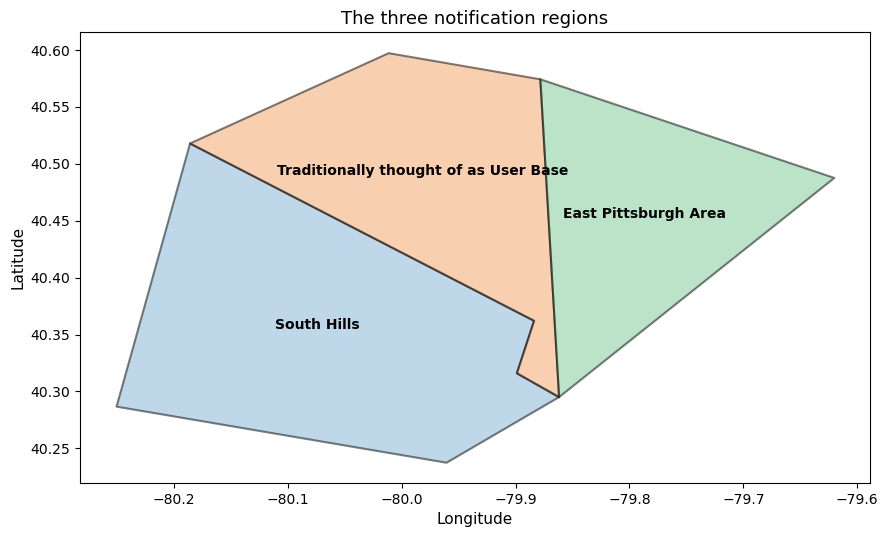

In [4]:
fig, ax = plt.subplots(figsize=(9, 8))

region_colors = ['#7fb3d5', '#f4a261', '#76c893']
for (idx, row), color in zip(regions.iterrows(), region_colors):
    gpd.GeoSeries([row.geometry]).plot(
        ax=ax, color=color, alpha=0.5, edgecolor='black', linewidth=1.5
    )
    centroid = row.geometry.centroid
    ax.annotate(row['Name'], (centroid.x, centroid.y),
                ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('The three notification regions', fontsize=13)
plt.tight_layout()
plt.savefig('region_boundaries.png', dpi=130, bbox_inches='tight')
plt.show()

## Combine facility rasters (same as the ranking notebook)

Load each facility's TIF for a given day and sum them pixel-by-pixel onto a shared canvas. If your facilities are perfectly aligned (same bounds), this is a direct add; if offset, this uses the pixel-offset stitching approach from the earlier notebook. Check which applies to your facilities and use the matching version below.

In [5]:
def combine_facilities(date_str, facility_dirs, nodata=0.0):
    """
    Load each facility's raster for date_str and sum pixel-by-pixel.
    Assumes all facilities share the same grid (same bounds, shape, CRS).
    If your facilities are offset, swap this for the pixel-offset stitching
    version from the day-ranking notebook.
    """
    combined = None
    meta = None
    sources = []

    for name, folder in facility_dirs.items():
        fpath = os.path.join(folder, f'{date_str}.tif')
        if not os.path.exists(fpath):
            continue
        with rasterio.open(fpath) as src:
            data = src.read(1).astype(np.float32)
            if meta is None:
                meta = src.meta.copy()
                combined = np.zeros_like(data)
        data[data == nodata] = 0.0
        combined += data
        sources.append(name)

    return combined, meta, sources


# Discover all available dates
all_dates = set()
for name, folder in FACILITY_DIRS.items():
    files = glob.glob(os.path.join(folder, '*.tif'))
    all_dates |= {os.path.basename(f).replace('.tif', '') for f in files}
all_dates = sorted(all_dates)
print(f'Total dates available: {len(all_dates)}')

# Test on one date to get raster metadata (needed for region masking)
test_arr, test_meta, test_sources = combine_facilities(all_dates[0], FACILITY_DIRS)
print(f'Test combine: {all_dates[0]}, facilities: {test_sources}, shape: {test_arr.shape}')

Total dates available: 366
Test combine: 20240101, facilities: ['facility_A', 'facility_B', 'facility_C'], shape: (601, 601)


## Build a region mask for the raster grid

A "mask" here is a boolean array the same shape as our pollution raster (601×601), where `True` means "this pixel falls inside the region's boundary" and `False` means it doesn't.

We build one mask per region using `geometry_mask` from rasterio, which takes a polygon and a raster's coordinate transform and figures out exactly which pixels fall inside the shape. Once we have these three masks, computing a region's pollution sum on any day is just: take the full combined raster, multiply by the region's mask (zeroing out everything outside it), and sum what's left.

In [6]:
def build_region_masks(regions_gdf, raster_transform, raster_shape):
    """
    For each region polygon, build a boolean mask over the raster grid:
    True = pixel center falls inside this region.

    geometry_mask returns True for pixels OUTSIDE the shape by default
    (it's designed for masking things out), so we invert it with
    invert=True to get True = inside the region instead.
    """
    masks = {}
    for _, row in regions_gdf.iterrows():
        mask = geometry_mask(
            [row.geometry],
            out_shape=raster_shape,
            transform=raster_transform,
            invert=True   # True = inside the polygon
        )
        masks[row['Name']] = mask
    return masks


region_masks = build_region_masks(regions, test_meta['transform'], test_arr.shape)

print('Region masks built:')
for name, mask in region_masks.items():
    print(f'  {name}: {mask.sum():,} pixels inside region (out of {mask.size:,} total)')

Region masks built:
  South Hills: 5,673 pixels inside region (out of 361,201 total)
  Traditionally thought of as User Base: 3,912 pixels inside region (out of 361,201 total)
  East Pittsburgh Area: 3,187 pixels inside region (out of 361,201 total)


### Visual check: do the masks line up with the regions?

Plotting each mask should produce a shape that visually matches the polygon from earlier

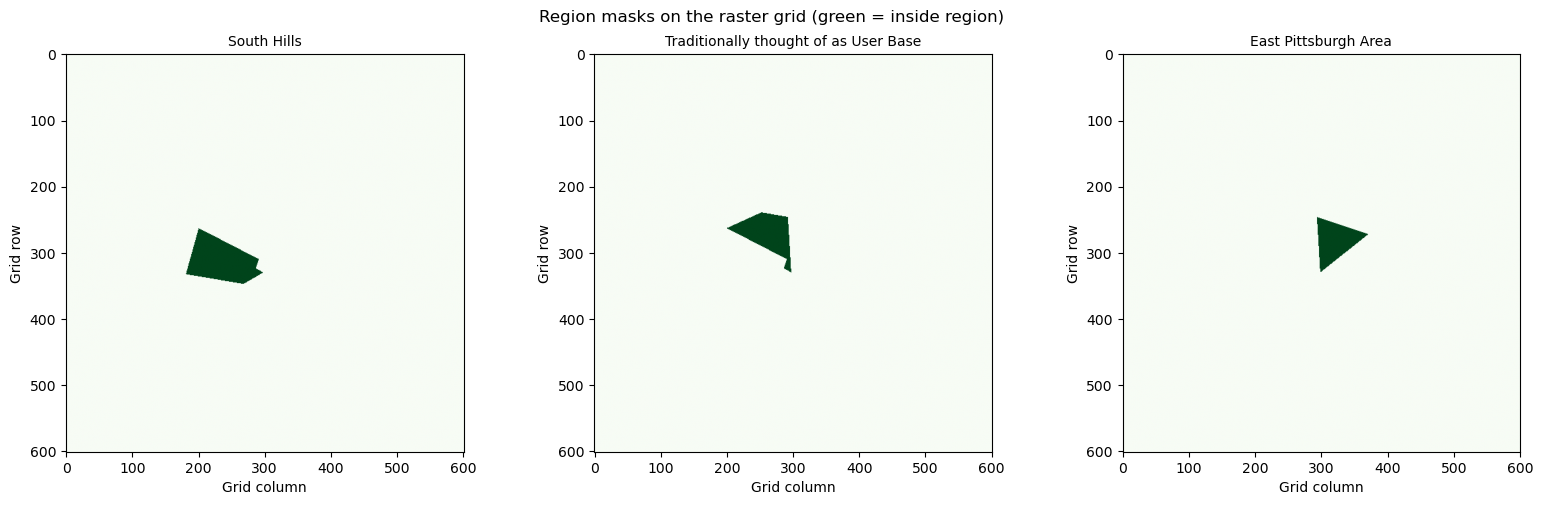

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, mask) in zip(axes, region_masks.items()):
    ax.imshow(mask, cmap='Greens', origin='upper')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Grid column')
    ax.set_ylabel('Grid row')

plt.suptitle('Region masks on the raster grid (green = inside region)', fontsize=12)
plt.tight_layout()
plt.savefig('region_masks_check.png', dpi=120, bbox_inches='tight')
plt.show()

## Compute a regional pollution sum for every day

For each day: combine the facility rasters as before, then for each region, multiply the combined raster by that region's mask and sum what's left. This gives us a separate pollution sum for South Hills, the user base area, and East Pittsburgh.

In [10]:
import time
t_start = time.time()

records = []
for date_str in all_dates:
    combined, meta, sources = combine_facilities(date_str, FACILITY_DIRS)
    if combined is None:
        continue
    row = {'date': pd.to_datetime(date_str, format='%Y%m%d'), 'date_str': date_str,
           'facilities': ', '.join(sources)}
    for region_name, mask in region_masks.items():
        masked = combined * mask
        row[f'sum_{region_name}'] = float(masked.sum())
        row[f'max_{region_name}'] = float(masked.max())
        row[f'nonzero_{region_name}'] = int((masked > 0).sum())
    records.append(row)

daily_regional = pd.DataFrame(records).sort_values('date').reset_index(drop=True)
print(f'Total time: {time.time() - t_start:.2f} seconds')
print(f'Processed {len(daily_regional)} days')

Total time: 43.25 seconds
Processed 366 days


In [11]:
records = []

for date_str in all_dates:
    combined, meta, sources = combine_facilities(date_str, FACILITY_DIRS)
    if combined is None:
        continue

    row = {
        'date':     pd.to_datetime(date_str, format='%Y%m%d'),
        'date_str': date_str,
        'facilities': ', '.join(sources),
    }

    for region_name, mask in region_masks.items():
        masked = combined * mask          # zero out everything outside the region
        row[f'sum_{region_name}']    = float(masked.sum())
        row[f'max_{region_name}']    = float(masked.max())
        row[f'nonzero_{region_name}'] = int((masked > 0).sum())

    records.append(row)

daily_regional = pd.DataFrame(records).sort_values('date').reset_index(drop=True)

print(f'Processed {len(daily_regional)} days across {len(region_masks)} regions')
print()
sum_cols = [f'sum_{name}' for name in region_masks.keys()]
print(daily_regional[['date_str'] + sum_cols].head(10).to_string(index=False))

Processed 366 days across 3 regions

date_str  sum_South Hills  sum_Traditionally thought of as User Base  sum_East Pittsburgh Area
20240101         0.000000                                   0.000000               2274.988281
20240102         0.000000                                   0.000000               3000.232910
20240103         0.000000                                   0.000000               4590.273438
20240104         0.000000                                   0.000000               1584.937256
20240105      4593.390625                                2207.216309               3025.245605
20240106      2978.141113                                2417.324707               4377.092773
20240107         0.000000                                   0.000000               2712.385742
20240108      1406.594604                                2012.889282               2012.139526
20240109        37.162495                                3020.862549               1128.512939
20240110     

## Rank days independently within each region

 Instead of one global ranking, each region's days get ranked against *that region's own history*. South Hills' top 10% is based on South Hills' own distribution of pollution sums, completely independent of how bad things are in East Pittsburgh that day.

In [12]:
region_thresholds = {}

for region_name in region_masks.keys():
    sum_col = f'sum_{region_name}'
    rank_col = f'rank_{region_name}'
    notify_col = f'notify_{region_name}'

    threshold = daily_regional[sum_col].quantile(1 - TOP_FRACTION)
    region_thresholds[region_name] = threshold

    daily_regional[rank_col] = daily_regional[sum_col].rank(ascending=False, method='min').astype(int)
    daily_regional[notify_col] = daily_regional[sum_col] >= threshold

    n_notify = daily_regional[notify_col].sum()
    print(f'{region_name}:')
    print(f'  Threshold (top {TOP_FRACTION*100:.0f}%): {threshold:.1f}')
    print(f'  Notification days: {n_notify} / {len(daily_regional)}')
    print()

South Hills:
  Threshold (top 10%): 3326.6
  Notification days: 37 / 366

Traditionally thought of as User Base:
  Threshold (top 10%): 4599.5
  Notification days: 37 / 366

East Pittsburgh Area:
  Threshold (top 10%): 6434.6
  Notification days: 37 / 366



## Assign smell reports to a region

Each smell report has a latitude and longitude. We turn each report into a point and check which region polygon (if any) contains it. 

In [13]:
raw_smell = pd.read_csv(SMELL_REPORTS_CSV)
print(f'Raw smell reports: {len(raw_smell):,}')

filtered_smell = raw_smell[raw_smell['smell value'] >= MIN_SMELL_VALUE].copy()
print(f'After filtering to ≥{MIN_SMELL_VALUE}: {len(filtered_smell):,}')

# Build a GeoDataFrame of report locations
geometry = [
    Point(lon, lat) for lon, lat in
    zip(filtered_smell['skewed longitude'], filtered_smell['skewed latitude'])
]
smell_gdf = gpd.GeoDataFrame(filtered_smell, geometry=geometry, crs='EPSG:4326')

# Spatial join: for each report point, find which region polygon contains it
smell_with_region = gpd.sjoin(
    smell_gdf, regions[['Name', 'geometry']],
    how='left', predicate='within'
)

n_assigned = smell_with_region['Name'].notna().sum()
n_outside  = smell_with_region['Name'].isna().sum()
print(f'\nReports assigned to a region: {n_assigned:,}')
print(f'Reports outside all three regions: {n_outside:,}')
print(f'\nReports per region:')
print(smell_with_region['Name'].value_counts().to_string())

Raw smell reports: 11,608
After filtering to ≥3: 10,594

Reports assigned to a region: 10,315
Reports outside all three regions: 279

Reports per region:
Name
Traditionally thought of as User Base    6774
South Hills                              2790
East Pittsburgh Area                      751


### Quick visual check — are the reports landing where expected?

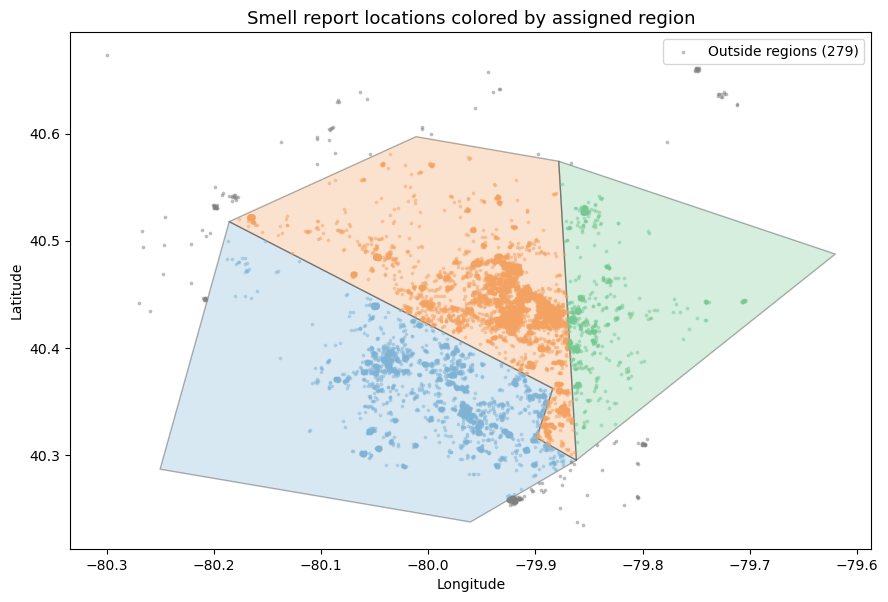

In [14]:
fig, ax = plt.subplots(figsize=(9, 8))

for (idx, row), color in zip(regions.iterrows(), region_colors):
    gpd.GeoSeries([row.geometry]).plot(ax=ax, color=color, alpha=0.3, edgecolor='black')

# Plot reports colored by assigned region, grey for unassigned
for name, color in zip(regions['Name'], region_colors):
    subset = smell_with_region[smell_with_region['Name'] == name]
    ax.scatter(subset.geometry.x, subset.geometry.y, s=3, color=color, alpha=0.4)

unassigned = smell_with_region[smell_with_region['Name'].isna()]
ax.scatter(unassigned.geometry.x, unassigned.geometry.y, s=3, color='grey', alpha=0.4,
           label=f'Outside regions ({len(unassigned):,})')

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Smell report locations colored by assigned region', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('smell_reports_by_region.png', dpi=130, bbox_inches='tight')
plt.show()

## Step 9 Aggregate smell reports to daily counts, per region

Grouped by both date and region, each region gets its own daily report count.

In [ ]:
smell_with_region['date'] = pd.to_datetime(
    smell_with_region['date & time'].str[:10], format='%m/%d/%Y'
)
smell_with_region['date_str'] = smell_with_region['date'].dt.strftime('%Y%m%d')

# Drop reports that didn't fall inside any region, bc can't assign them a regional comparison
smell_regional = smell_with_region.dropna(subset=['Name'])

smell_daily_by_region = (
    smell_regional.groupby(['date_str', 'Name'])
    .agg(n_reports=('smell value', 'count'), mean_smell=('smell value', 'mean'))
    .reset_index()
)

print(f'Daily regional smell records: {len(smell_daily_by_region)}')
print(smell_daily_by_region.head(10).to_string(index=False))

Daily regional smell records: 916
date_str                                  Name  n_reports  mean_smell
20240101 Traditionally thought of as User Base          2    4.000000
20240102                  East Pittsburgh Area          4    4.000000
20240102                           South Hills          3    3.333333
20240102 Traditionally thought of as User Base          1    3.000000
20240103 Traditionally thought of as User Base          1    3.000000
20240104                           South Hills          1    3.000000
20240104 Traditionally thought of as User Base          1    4.000000
20240105                  East Pittsburgh Area          1    4.000000
20240105                           South Hills          8    4.250000
20240105 Traditionally thought of as User Base         19    4.210526


## Merge regional plume data with regional smell data

We build one combined table: every date × every region, with that region's plume sum, notification flag, and smell report count side by side. 

In [16]:
region_names = list(region_masks.keys())

# Reshape daily_regional from wide (one row per day, columns per region)
# to long (one row per day x region) so it merges cleanly with smell data
long_rows = []
for _, row in daily_regional.iterrows():
    for region in region_names:
        long_rows.append({
            'date_str':   row['date_str'],
            'Name':       region,
            'regional_sum': row[f'sum_{region}'],
            'regional_max': row[f'max_{region}'],
            'rank':         row[f'rank_{region}'],
            'notify':       row[f'notify_{region}'],
        })
plume_long = pd.DataFrame(long_rows)

# Merge with smell data on (date, region)
region_merged = plume_long.merge(
    smell_daily_by_region, on=['date_str', 'Name'], how='left'
)
region_merged['n_reports']  = region_merged['n_reports'].fillna(0).astype(int)
region_merged['mean_smell'] = region_merged['mean_smell'].fillna(0)

print(f'Combined region-day table: {len(region_merged)} rows '
      f'({len(daily_regional)} days × {len(region_names)} regions)')
print()
print(region_merged.head(9).to_string(index=False))

Combined region-day table: 1098 rows (366 days × 3 regions)

date_str                                  Name  regional_sum  regional_max  rank  notify  n_reports  mean_smell
20240101                           South Hills      0.000000      0.000000   247   False          0    0.000000
20240101 Traditionally thought of as User Base      0.000000      0.000000   312   False          2    4.000000
20240101                  East Pittsburgh Area   2274.988281    120.925629   264   False          0    0.000000
20240102                           South Hills      0.000000      0.000000   247   False          3    3.333333
20240102 Traditionally thought of as User Base      0.000000      0.000000   312   False          1    3.000000
20240102                  East Pittsburgh Area   3000.232910    126.853203   213   False          4    4.000000
20240103                           South Hills      0.000000      0.000000   247   False          0    0.000000
20240103 Traditionally thought of as User B

## Compare false positive / false negative rates: regional vs. global

For each region, we define "high smell" as that region's own top 25% of report days (a region-specific threshold, same logic as the plume side). Then we check: on days the regional model would notify, how often does the region's community agree? And on days the *old global* model would have notified, how often was *this specific region* actually affected?

This tells us directly whether splitting into regions reduces the false positive problem (global model notifies, but this region wasn't affected) and the false negative problem (this region had a real local event, but the global model didn't fire because the rest of the domain was quiet).

In [17]:
# Load the OLD global daily rankings for comparison (from the earlier notebook)
GLOBAL_RANKINGS_CSV = './daily_rankings.csv'
global_daily = pd.read_csv(GLOBAL_RANKINGS_CSV)
global_daily['date_str'] = pd.to_datetime(global_daily['date']).dt.strftime('%Y%m%d')
global_threshold = global_daily['regional_sum'].quantile(1 - TOP_FRACTION)
global_daily['notify_global'] = global_daily['regional_sum'] >= global_threshold

# Attach the global notify flag to every region-day row
region_merged = region_merged.merge(
    global_daily[['date_str', 'notify_global']], on='date_str', how='left'
)
region_merged['notify_global'] = region_merged['notify_global'].fillna(False)

print('=== Per-region comparison: regional notify vs. global notify ===\n')

summary_rows = []
for region in region_names:
    sub = region_merged[region_merged['Name'] == region].copy()
    smell_high = sub['n_reports'].quantile(0.75)
    sub['smell_high'] = sub['n_reports'] >= smell_high

    # REGIONAL approach
    reg_false_pos = ((sub['notify'] == True) & (sub['smell_high'] == False)).sum()
    reg_false_neg = ((sub['notify'] == False) & (sub['smell_high'] == True)).sum()
    reg_true_pos  = ((sub['notify'] == True) & (sub['smell_high'] == True)).sum()

    # GLOBAL approach, evaluated against THIS region's smell reports
    glob_false_pos = ((sub['notify_global'] == True) & (sub['smell_high'] == False)).sum()
    glob_false_neg = ((sub['notify_global'] == False) & (sub['smell_high'] == True)).sum()
    glob_true_pos  = ((sub['notify_global'] == True) & (sub['smell_high'] == True)).sum()

    summary_rows.append({
        'Region': region,
        'Smell-high threshold': f'{smell_high:.0f}',
        'Regional: True positives':  reg_true_pos,
        'Regional: False positives': reg_false_pos,
        'Regional: False negatives': reg_false_neg,
        'Global: True positives':  glob_true_pos,
        'Global: False positives': glob_false_pos,
        'Global: False negatives': glob_false_neg,
    })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

=== Per-region comparison: regional notify vs. global notify ===

                               Region Smell-high threshold  Regional: True positives  Regional: False positives  Regional: False negatives  Global: True positives  Global: False positives  Global: False negatives
                          South Hills                    9                        21                         16                         76                      19                       18                       78
Traditionally thought of as User Base                   21                        26                         11                         69                      15                       22                       80
                 East Pittsburgh Area                    3                        24                         13                         89                      15                       22                       98


### Visualizing the comparison

A grouped bar chart, one group per region, comparing false positives and false negatives between the global and regional approaches. Lower bars are better, since fewer false positives means fewer wasted notifications, fewer false negatives means fewer missed bad days.

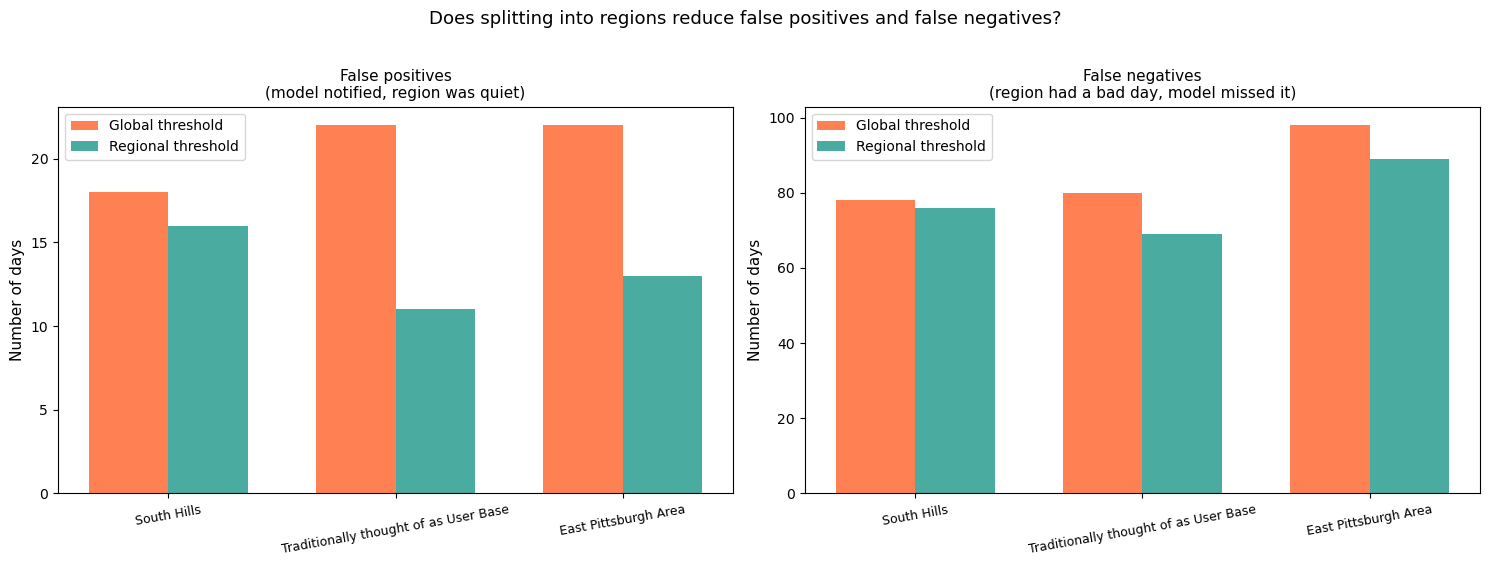

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

x = np.arange(len(region_names))
width = 0.35

# False positives
axes[0].bar(x - width/2, summary['Global: False positives'], width,
            label='Global threshold', color='#FF6B35', alpha=0.85)
axes[0].bar(x + width/2, summary['Regional: False positives'], width,
            label='Regional threshold', color='#2A9D8F', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(region_names, fontsize=9, rotation=10)
axes[0].set_ylabel('Number of days', fontsize=11)
axes[0].set_title('False positives\n(model notified, region was quiet)', fontsize=11)
axes[0].legend(fontsize=10)

# False negatives
axes[1].bar(x - width/2, summary['Global: False negatives'], width,
            label='Global threshold', color='#FF6B35', alpha=0.85)
axes[1].bar(x + width/2, summary['Regional: False negatives'], width,
            label='Regional threshold', color='#2A9D8F', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(region_names, fontsize=9, rotation=10)
axes[1].set_ylabel('Number of days', fontsize=11)
axes[1].set_title('False negatives\n(region had a bad day, model missed it)', fontsize=11)
axes[1].legend(fontsize=10)

plt.suptitle('Does splitting into regions reduce false positives and false negatives?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('regional_vs_global_errors.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── FALSE POSITIVE / FALSE NEGATIVE RATES AS PERCENTAGES ────────────────────

total_days = len(daily_regional)

print('=== FP/FN rates: regional vs. global threshold ===\n')

summary_pct_rows = []
for region in region_names:
    sub = region_merged[region_merged['Name'] == region].copy()
    smell_high = sub['n_reports'].quantile(0.75)
    sub['smell_high'] = sub['n_reports'] >= smell_high

    # Counts
    reg_tp = ((sub['notify'])  & (sub['smell_high'])).sum()
    reg_fp = ((sub['notify'])  & (~sub['smell_high'])).sum()
    reg_fn = ((~sub['notify']) & (sub['smell_high'])).sum()
    reg_notify_days = sub['notify'].sum()
    reg_smell_high_days = sub['smell_high'].sum()

    glob_tp = ((sub['notify_global'])  & (sub['smell_high'])).sum()
    glob_fp = ((sub['notify_global'])  & (~sub['smell_high'])).sum()
    glob_fn = ((~sub['notify_global']) & (sub['smell_high'])).sum()
    glob_notify_days = sub['notify_global'].sum()
    glob_smell_high_days = sub['smell_high'].sum()

    summary_pct_rows.append({
        'Region': region,

        # % of ALL days
        'Regional FP % of all days': round(100 * reg_fp / total_days, 1),
        'Regional FN % of all days': round(100 * reg_fn / total_days, 1),
        'Global FP % of all days':   round(100 * glob_fp / total_days, 1),
        'Global FN % of all days':   round(100 * glob_fn / total_days, 1),

        # % of notification days (precision-style: of days we notified, how many were wrong?)
        'Regional FP % of notify days': round(100 * reg_fp / reg_notify_days, 1) if reg_notify_days else 0,
        'Global FP % of notify days':   round(100 * glob_fp / glob_notify_days, 1) if glob_notify_days else 0,

        # % of high-smell days (recall-style: of days that were actually bad, how many did we miss?)
        'Regional FN % of high-smell days': round(100 * reg_fn / reg_smell_high_days, 1) if reg_smell_high_days else 0,
        'Global FN % of high-smell days':   round(100 * glob_fn / glob_smell_high_days, 1) if glob_smell_high_days else 0,
    })

summary_pct = pd.DataFrame(summary_pct_rows)

print('--- As % of ALL days in the year ---')
print(summary_pct[['Region', 'Regional FP % of all days', 'Global FP % of all days',
                   'Regional FN % of all days', 'Global FN % of all days']].to_string(index=False))

print('\n--- FP as % of notification days sent (precision) ---')
print(summary_pct[['Region', 'Regional FP % of notify days', 'Global FP % of notify days']].to_string(index=False))

print('\n--- FN as % of actual high-smell days (miss rate / 1 - recall) ---')
print(summary_pct[['Region', 'Regional FN % of high-smell days', 'Global FN % of high-smell days']].to_string(index=False))

summary_pct.to_csv('regional_vs_global_fp_fn_percentages.csv', index=False)
print('\nSaved: regional_vs_global_fp_fn_percentages.csv')

=== FP/FN rates: regional vs. global threshold ===

--- As % of ALL days in the year ---
                               Region  Regional FP % of all days  Global FP % of all days  Regional FN % of all days  Global FN % of all days
                          South Hills                        4.4                      4.9                       20.8                     21.3
Traditionally thought of as User Base                        3.0                      6.0                       18.9                     21.9
                 East Pittsburgh Area                        3.6                      6.0                       24.3                     26.8

--- FP as % of notification days sent (precision) ---
                               Region  Regional FP % of notify days  Global FP % of notify days
                          South Hills                          43.2                        48.6
Traditionally thought of as User Base                          29.7                        59.5


## Save outputs

In [ ]:
daily_regional.to_csv('daily_regional_sums.csv', index=False)
region_merged.to_csv('region_smell_plume_merged.csv', index=False)
summary.to_csv('regional_vs_global_comparison.csv', index=False)

print('Saved:')
print('  daily_regional_sums.csv          — one row per day, sum/max/nonzero per region')
print('  region_smell_plume_merged.csv    — one row per day x region, plume + smell + notify flags')
print('  regional_vs_global_comparison.csv — false positive/negative summary table')